In [1]:
import networkx as nx
from multiprocessing import cpu_count
from netective.utils import run_parallel
from netective.pipeline import compute_props, create_symmetric_heatmap, plot_distributions, plot_scalars, pairwise_pearson_correlation

from freyrelab.regnets.regnet import RegNet
import re
import os
import numpy as np

## Code

### Extracción de redes

In [2]:
def get_mouse_names(root, code_names):
    name = re.split('mouse_net', root)
    name = name[1]
    name = name.replace('\\','')
    return code_names[name]

def extract_networks(directory_name=str, files_ignore=list, cols=tuple, feo=True, code_names=dict):
    networks = {}
    for root, dir, files in os.walk(directory_name):
        if len(files) != 0 and files[0] not in files_ignore:
          path = os.path.join(os.getcwd(), root, files[0])
          net = RegNet()
          if feo:
               f = np.genfromtxt(path, dtype= str, delimiter='\t', usecols= cols)
               net.add_edges_from(f)
          else:
               net = nx.read_edgelist(path)
          name = get_mouse_names(root, code_names)
          networks[name] = net
    return networks

In [3]:
mm9CellTypeValues = { "m3134-DS8497" : 			  "mammary adenocarcinoma",
                        "m416B-DS14099" : 		  "CD34+ myeloid progenitor",
                        "mA20-DS16695" :            "B-lymphocyte reticulum cell sarcoma",
                        "mATn-DS17070" :            "activated T-naive cell",
                        "mATr-DS20149" :            "ATr",
                        "mB-DS16168" :              "B-cell, replicate 1",
                        "mB-DS17866" :              "B-cell, replicate 2",
                        "mBrain-DS12727" :          "normal brain",
                        "mCJ7-DS13320" :            "embryonic stem cells via 129S1/SVImJ mice",
                        "MEL-DS13036" :             "leukemia, K562 analog",
                        "mfBrain-DS14536" :         "fetal brain",
                        "mGenitalFatPad-DS18182" :  "genital adipose tissue",
                        "mHeart-DS18138" :          "normal heart",
                        "mKidney-DS13948" :         "normal kidney",
                        "mLiver-DS14605" :          "normal liver",
                        "mLung-DS14479" :           "normal lung",
                        "mNIH_3T3-DS16900" :        "fibroblast",
                        "mRetina-DS20004" :         "normal retina", 
                        "mThymus-DS18819" :         "normal thymus",
                        "mTN-DS16171" :             "TN, replicate 1",
                        "mTN-DS17080" :             "TN, replicate 2",
                        "mTR-DS17864" :             "regulatory T-cells",
                        "ZhBTc4-DS15236" :          "embryonic stem cells, +6 hrs doxycycline",
                        "ZhBTc4-DS17562" :          "embryonic stem cells, +24 hrs doxycycline",
                        "ZhBTc4-DS17616" :          "embryonic stem cells, control"
                        }

networks = extract_networks('..\data\mouse_net', [], (3,4), feo=True, code_names=mm9CellTypeValues)

In [4]:
networks

{'mammary adenocarcinoma': <freyrelab.regnets.regnet.RegNet at 0x185e90ac760>,
 'CD34+ myeloid progenitor': <freyrelab.regnets.regnet.RegNet at 0x185e157c760>,
 'B-lymphocyte reticulum cell sarcoma': <freyrelab.regnets.regnet.RegNet at 0x185e15a2640>,
 'activated T-naive cell': <freyrelab.regnets.regnet.RegNet at 0x185e1686580>,
 'ATr': <freyrelab.regnets.regnet.RegNet at 0x185e15a2460>,
 'B-cell, replicate 1': <freyrelab.regnets.regnet.RegNet at 0x185e157c430>,
 'B-cell, replicate 2': <freyrelab.regnets.regnet.RegNet at 0x185e15a23a0>,
 'normal brain': <freyrelab.regnets.regnet.RegNet at 0x185e159dfd0>,
 'embryonic stem cells via 129S1/SVImJ mice': <freyrelab.regnets.regnet.RegNet at 0x185e159da90>,
 'leukemia, K562 analog': <freyrelab.regnets.regnet.RegNet at 0x185e168b8e0>,
 'fetal brain': <freyrelab.regnets.regnet.RegNet at 0x185e15a2040>,
 'genital adipose tissue': <freyrelab.regnets.regnet.RegNet at 0x185e168bcd0>,
 'normal heart': <freyrelab.regnets.regnet.RegNet at 0x185e157c8e

In [5]:
workers = cpu_count()-1
print(workers)
data = [
    list(networks.values()),
    list(networks.keys()),
    [None] * len(networks),
    #['all'] * len(networks),
]



15


In [6]:
results = run_parallel(compute_props, data, workers)

25it [02:48,  6.76s/it]                      


In [7]:
scalar_arrays = results['scalars']
dist_moments_arrays = results['distributions']

C:\Users\jmere\AppData\Local\Temp\ipykernel_6964\1954940516.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_scalar.show()
C:\Users\jmere\AppData\Local\Temp\ipykernel_6964\1954940516.py:13: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_dist.show()


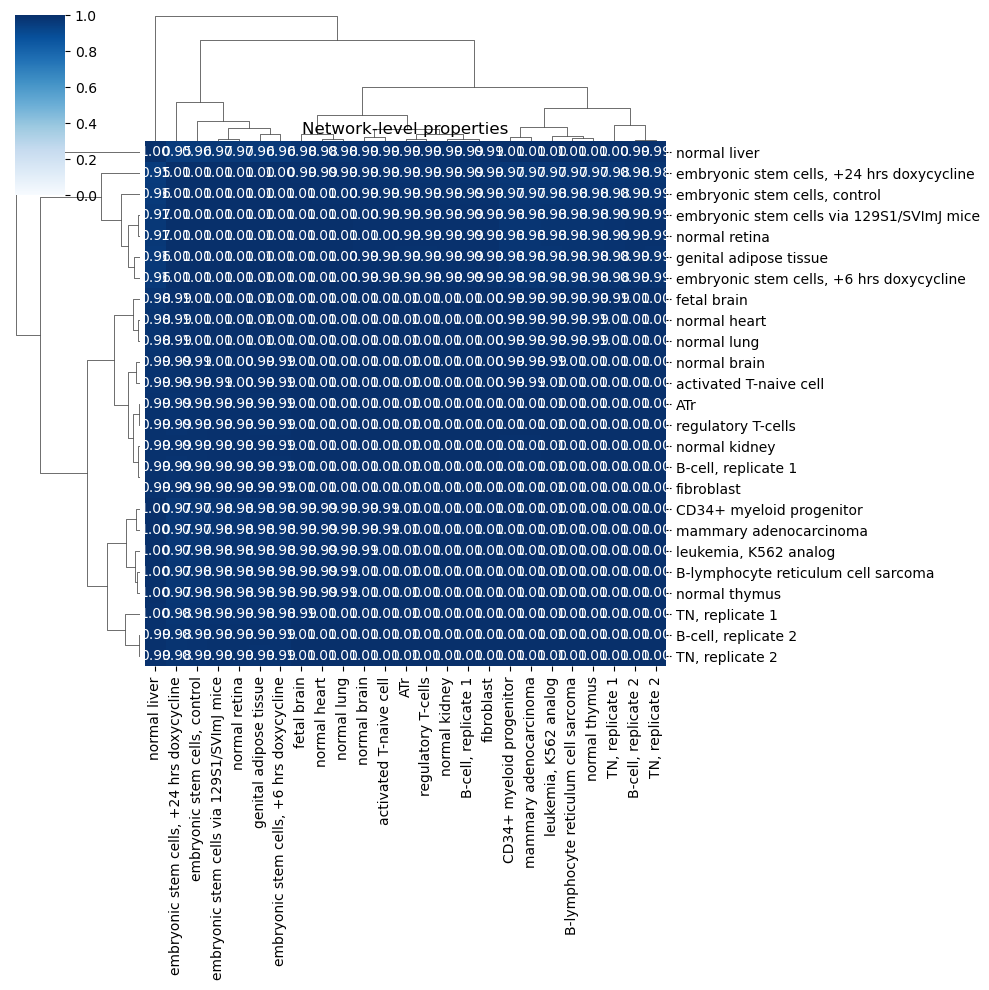

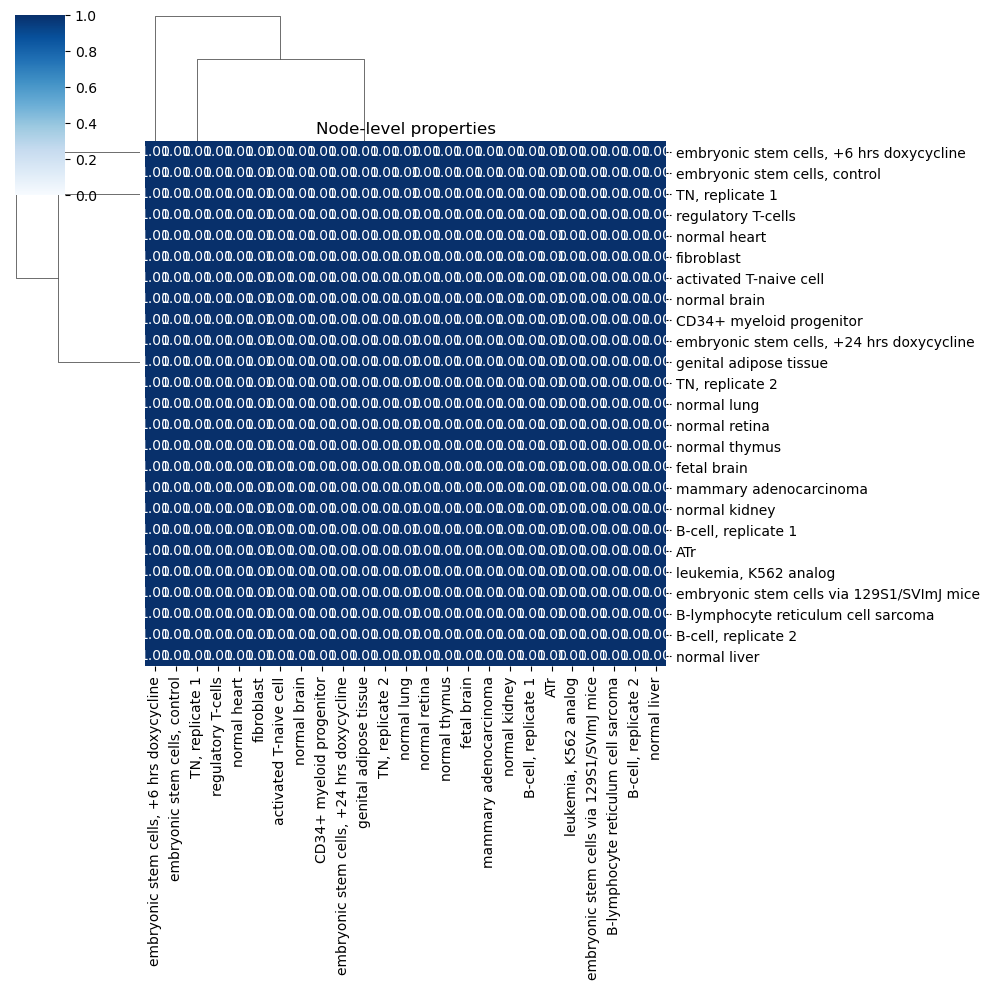

In [8]:
# Scalar properties
df = pairwise_pearson_correlation(scalar_arrays)
fig_scalar, _ = create_symmetric_heatmap(
    df, title=f"Network-level properties"
)

# Distribution properties
df = pairwise_pearson_correlation(dist_moments_arrays)
fig_dist, _ = create_symmetric_heatmap(df, title=f"Node-level properties")


fig_scalar.show()
fig_dist.show()